In [ ]:
# Import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import confusion_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from mrmr import mrmr_classif

import os
import joblib

In [2]:
file = "RF_none.joblib"
save_output = True

In [3]:
# Load data
X_train = pd.read_excel("Data/X_train.xlsx").iloc[:, 1:]
X_test  = pd.read_excel("Data/X_test.xlsx").iloc[:, 1:]
# Ensure that the order of features in the test set matches that of the training set
X_test = X_test[X_train.columns]

y_train = pd.read_excel("Data/y_train.xlsx").iloc[:, 1].values
y_test  = pd.read_excel("Data/y_test.xlsx").iloc[:, 1].values

y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
class MRMRSelector(BaseEstimator, TransformerMixin):
    def __init__(self, K=10):
        self.K = K
        self.selected_features_ = None

    def fit(self, X, y):
        # Convert through numpy first to guarantee a clean 0-based RangeIndex on
        # both X_df and y_s. Without this, CV-sliced DataFrames keep their original
        # non-contiguous index while pd.Series(y) gets 0..n, causing mrmr's internal
        # boolean indexer to raise IndexingError on index misalignment.
        Xarr = np.array(X)
        cols = getattr(X, "columns", range(Xarr.shape[1]))
        X_df = pd.DataFrame(Xarr, columns=cols)
        y_s  = pd.Series(np.array(y).ravel())
        self.selected_features_ = mrmr_classif(X_df, y_s, K=self.K)
        return self

    def transform(self, X):
        Xarr = np.array(X)
        cols = getattr(X, "columns", range(Xarr.shape[1]))
        X_df = pd.DataFrame(Xarr, columns=cols)
        return X_df[self.selected_features_].values

In [5]:
base = file.replace(".joblib", "")
name, fs = base.rsplit("_", 1)

pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
if fs != "none":
    # Get selected features - try multiple methods for compatibility
    if hasattr(fs_step, 'get_support'):
        mask = fs_step.get_support()
        feature_names = fs_step.feature_names_in_
        features_model = feature_names[mask]
    elif hasattr(fs_step, 'selected_features_'):
        # Direct access to selected features (e.g., MRMRSelector)
        features_model = np.array(fs_step.selected_features_)
    elif hasattr(fs_step, 'get_feature_names_out'):
        # For sklearn selectors that support get_feature_names_out
        features_model = fs_step.get_feature_names_out()
    else:
        raise AttributeError(f"Cannot extract selected features from {type(fs_step).__name__}")
    
    X_tr = X_train[features_model].reset_index(drop=True)
    X_te  = X_test[features_model].reset_index(drop=True)
    print(f"Feature selection applied — {len(features_model)} features: {features_model}")
else:
    features_model = list(X_train.columns)
    X_tr = X_train.reset_index(drop=True)
    X_te  = X_test.reset_index(drop=True)
    print(f"No feature selection — using all {len(features_model)} features.")

m = pipeline.named_steps.get("model", None)

No feature selection — using all 23 features.


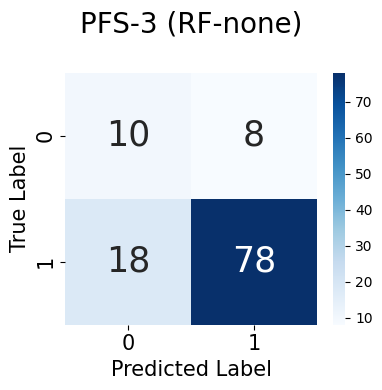

In [6]:
# Confusion matrix
y_pred = m.predict(X_te)

plt.figure(figsize=(4, 4))
sns_plot=sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", annot_kws={"size": 25})
sns_plot.set_title("PFS-3 (RF-none)\n", fontsize=20)
sns_plot.set_xlabel('Predicted Label', fontsize=15)
sns_plot.set_ylabel('True Label', fontsize=15)
sns_plot.tick_params(axis='both', which='major', labelsize=15)
fig = sns_plot.get_figure()
plt.tight_layout()
if save_output:
    path = f'Results/Matrix_{name}{fs}.png'
    fig.savefig(path, dpi=300, format="png")